<a href="https://colab.research.google.com/github/kovurusaiprabhanshu/Thyroid-Recurrence-Prediction-Using-k-Nearest-Neighbours/blob/main/Thyroid_Reccurence_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **kNN Analysis of Thyroid Reccurence**
Performing kNN analysis of Thyroid patient dataset, and exploring what algorithms, hyperparameters and metrics are optimal for predicting reccurence of Thyroid Cancer.

## **Data Analysis**

### 1. General Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [ ]:
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

In [ ]:
sns.set(color_codes = "True")

### 2. Loading Data

In [ ]:
df = pd.read_csv(r"C:\Users\Lasya\Downloads\Thyroid_Diff.csv")

In [ ]:
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [ ]:
print(df)

     Age Gender Smoking Hx Smoking Hx Radiothreapy          Thyroid Function  \
0     27      F      No         No              No                 Euthyroid   
1     34      F      No        Yes              No                 Euthyroid   
2     30      F      No         No              No                 Euthyroid   
3     62      F      No         No              No                 Euthyroid   
4     62      F      No         No              No                 Euthyroid   
..   ...    ...     ...        ...             ...                       ...   
378   72      M     Yes        Yes             Yes                 Euthyroid   
379   81      M     Yes         No             Yes                 Euthyroid   
380   72      M     Yes        Yes              No                 Euthyroid   
381   61      M     Yes        Yes             Yes  Clinical Hyperthyroidism   
382   67      M     Yes         No              No                 Euthyroid   

            Physical Examination Adenop

In [ ]:
print(df.shape)

(383, 17)


### 3. Checking whether the given data has any duplicates, and droping them from the dataset

In [ ]:
duplicate_rows_df = df[df.duplicated()]
print("Number of duplicated rows:",duplicate_rows_df);

Number of duplicated rows:      Age Gender Smoking Hx Smoking Hx Radiothreapy Thyroid Function  \
32    36      F      No         No              No        Euthyroid   
38    40      F      No         No              No        Euthyroid   
40    51      F      No         No              No        Euthyroid   
66    35      F      No         No              No        Euthyroid   
69    51      F      No         No              No        Euthyroid   
77    29      F      No         No              No        Euthyroid   
120   37      F      No         No              No        Euthyroid   
121   26      F      No         No              No        Euthyroid   
123   28      F      No         No              No        Euthyroid   
132   32      F      No         No              No        Euthyroid   
137   32      F      No         No              No        Euthyroid   
138   26      F      No         No              No        Euthyroid   
166   31      F      No         No              No

In [ ]:
print(duplicate_rows_df.shape)

(19, 17)


In [ ]:
df.drop_duplicates(inplace=True)

### 4. Checking for cases where **Thyroid Recurrision** occured

<Axes: xlabel='count', ylabel='Recurred'>

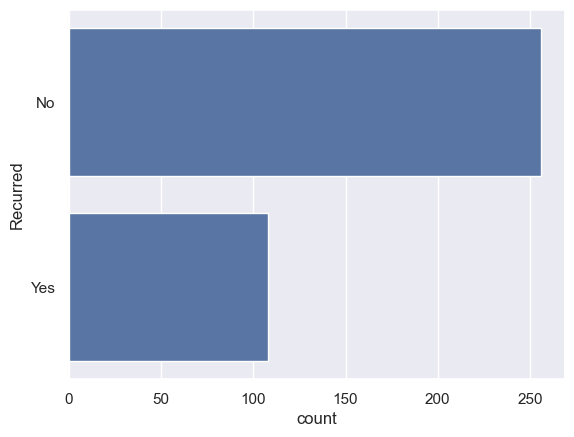

In [ ]:
sns.countplot(df, y="Recurred")

### 5. **Data Visualization** in order to better understand the data

In [ ]:
df['Physical Examination'].value_counts()

Physical Examination
Multinodular goiter            135
Single nodular goiter-right    127
Single nodular goiter-left      88
Normal                           7
Diffuse goiter                   7
Name: count, dtype: int64

<Axes: >

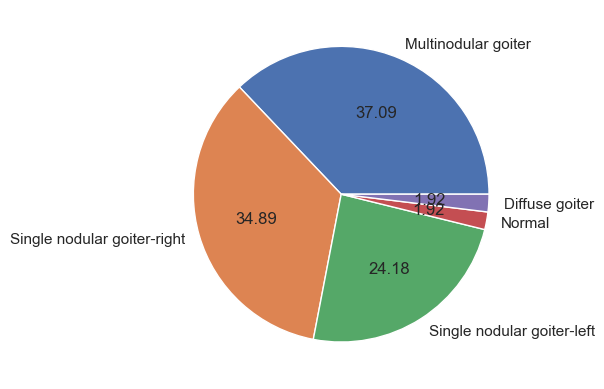

In [ ]:
df["Physical Examination"].value_counts().plot(kind='pie',autopct='%.2f') # autopct is used percentange on graph

In [ ]:
df['Risk'].value_counts()

Risk
Low             230
Intermediate    102
High             32
Name: count, dtype: int64

<Axes: xlabel='Risk', ylabel='Age'>

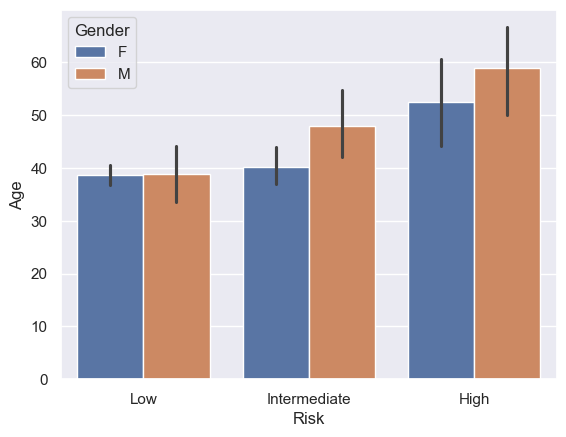

In [ ]:
sns.barplot(df,x="Risk",y="Age",hue="Gender")

<Axes: xlabel='Stage', ylabel='count'>

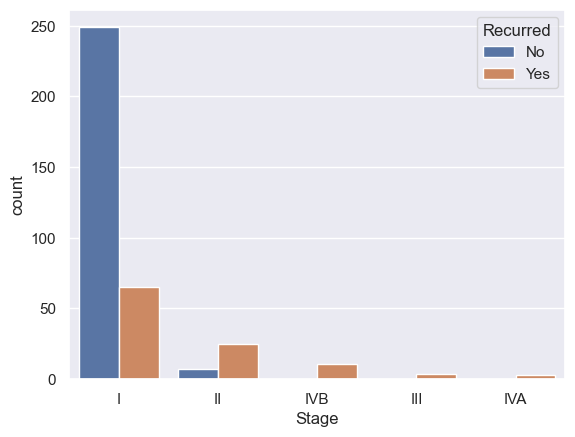

In [ ]:
sns.countplot(df, x="Stage",hue="Recurred")

<Axes: xlabel='Risk', ylabel='Age'>

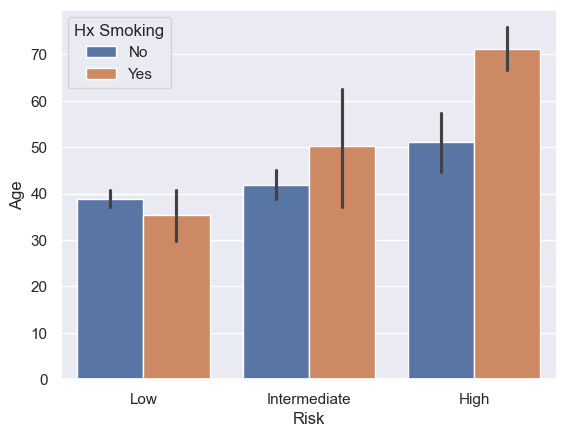

In [ ]:
sns.barplot(df,x="Risk",y="Age",hue="Hx Smoking")

<Axes: xlabel='Risk', ylabel='Age'>

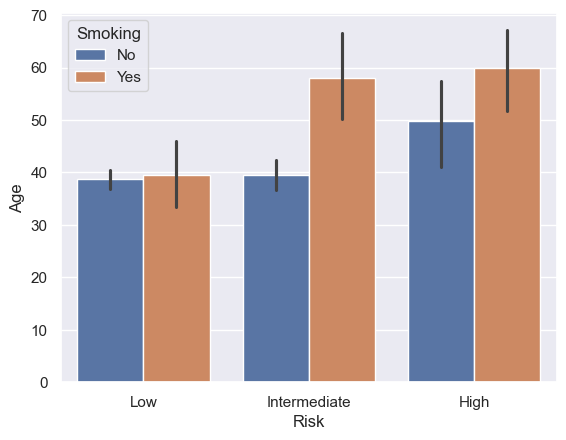

In [ ]:
sns.barplot(df,x="Risk",y="Age",hue="Smoking")

<Axes: xlabel='Stage', ylabel='count'>

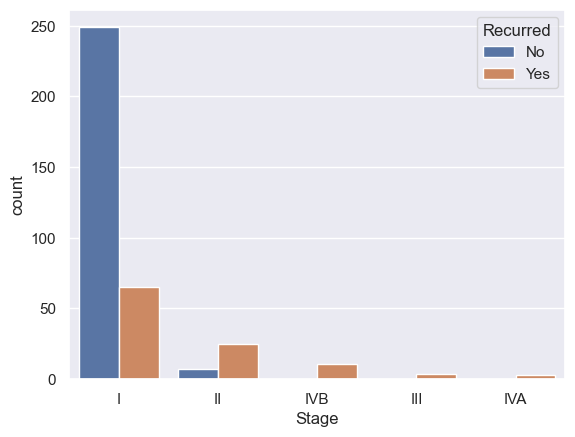

In [ ]:
sns.countplot(df, x="Stage",hue="Recurred")

<Axes: xlabel='Risk', ylabel='count'>

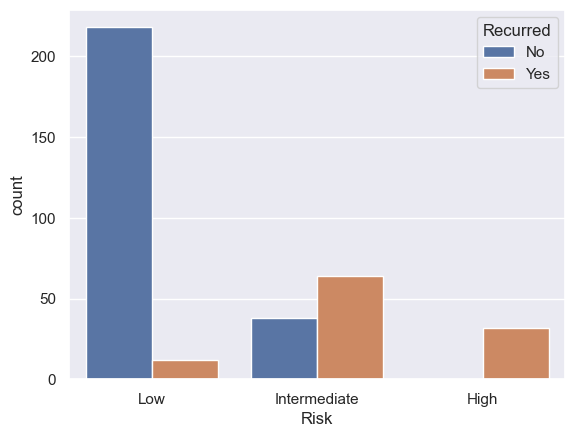

In [ ]:
sns.countplot(df, x="Risk",hue="Recurred")

In [ ]:
df["Gender"].value_counts()

Gender
F    293
M     71
Name: count, dtype: int64

### 5. **Data Encoding** to convert given data into a consistent label

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_Gender = LabelEncoder()
label_Smoking = LabelEncoder()
label_Smoking_History = LabelEncoder()
label_Radiotherapy_History = LabelEncoder()
label_Thyroid_Function = LabelEncoder()
label_Physical_Examination = LabelEncoder()
label_Adenopathy = LabelEncoder()
label_Pathology = LabelEncoder()
label_Focality = LabelEncoder()
label_Cancer_Metastasis = LabelEncoder()
label_Lymph_Nodes	 = LabelEncoder()
label_Stage = LabelEncoder()
label_Tumor = LabelEncoder()
label_Treatment_Response	= LabelEncoder()
label_= LabelEncoder()
label_Recurred = LabelEncoder()

In [ ]:
df['Gender'] = label_Gender.fit_transform(df['Gender'])
df['Smoking'] = label_Smoking.fit_transform(df['Smoking'])
df['Hx Smoking'] = label_Smoking_History.fit_transform(df['Hx Smoking'])
df['Hx Radiothreapy'] = label_Radiotherapy_History.fit_transform(df['Hx Radiothreapy'])
df['Thyroid Function'] = label_Thyroid_Function.fit_transform(df['Thyroid Function'])
df['Physical Examination'] = label_Physical_Examination.fit_transform(df['Physical Examination'])
df['Adenopathy'] = label_Adenopathy.fit_transform(df['Adenopathy'])
df['Pathology'] = label_Pathology.fit_transform(df['Pathology'])
df['Focality'] = label_Focality.fit_transform(df['Focality'])
df['M'] = label_Cancer_Metastasis.fit_transform(df['M'])
df['N'] = label_Lymph_Nodes	.fit_transform(df['N'])
df['T'] = label_Tumor	.fit_transform(df['T'])
df['Stage'] = label_Stage.fit_transform(df['Stage'])
df['Response'] = label_Treatment_Response.fit_transform(df['Response'])
df['Recurred'] = label_Recurred.fit_transform(df['Recurred'])

In [ ]:
print(df)

     Age  Gender  Smoking  Hx Smoking  Hx Radiothreapy  Thyroid Function  \
0     27       0        0           0                0                 2   
1     34       0        0           1                0                 2   
2     30       0        0           0                0                 2   
3     62       0        0           0                0                 2   
4     62       0        0           0                0                 2   
..   ...     ...      ...         ...              ...               ...   
378   72       1        1           1                1                 2   
379   81       1        1           0                1                 2   
380   72       1        1           1                0                 2   
381   61       1        1           1                1                 0   
382   67       1        1           0                0                 2   

     Physical Examination  Adenopathy  Pathology  Focality  Risk  T  N  M  \
0         

In [ ]:
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,0,0,0,0,2,3,3,2,1,Low,0,0,0,0,2,0
1,34,0,0,1,0,2,1,3,2,1,Low,0,0,0,0,1,0
2,30,0,0,0,0,2,4,3,2,1,Low,0,0,0,0,1,0
3,62,0,0,0,0,2,4,3,2,1,Low,0,0,0,0,1,0
4,62,0,0,0,0,2,1,3,2,0,Low,0,0,0,0,1,0


In [ ]:
df.value_counts()

Age  Gender  Smoking  Hx Smoking  Hx Radiothreapy  Thyroid Function  Physical Examination  Adenopathy  Pathology  Focality  Risk  T  N  M  Stage  Response  Recurred
27   0       0        0           0                2                 3                     3           2          1         Low   0  0  0  0      2         0           1
34   0       0        1           0                2                 1                     3           2          1         Low   0  0  0  0      1         0           1
30   0       0        0           0                2                 4                     3           2          1         Low   0  0  0  0      1         0           1
62   0       0        0           0                2                 4                     3           2          1         Low   0  0  0  0      1         0           1
                                                                     1                     3           2          0         Low   0  0  0  0      1        

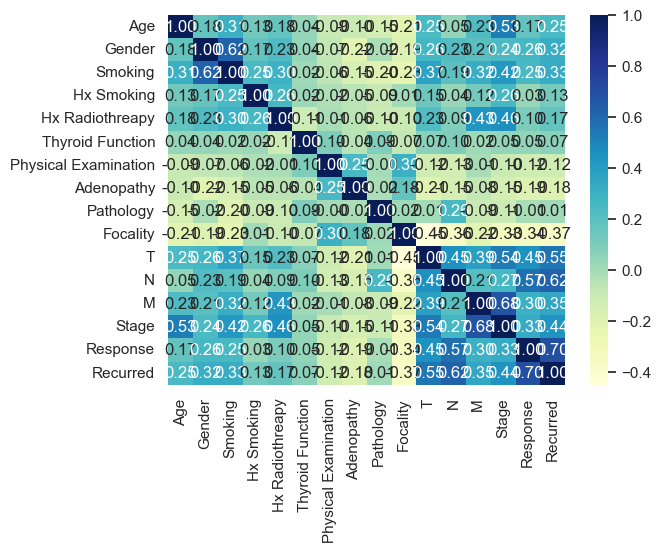

In [ ]:
sns.heatmap(df.select_dtypes(include=['number']).corr(),
            cmap="YlGnBu", annot=True, fmt=".2f")
plt.show()

<Axes: xlabel='Age'>

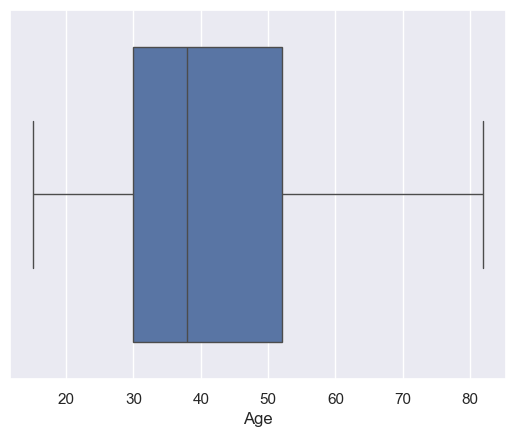

In [ ]:
sns.boxplot(x=df['Age'])

In [ ]:
x = df.drop('Recurred', axis=1)
y = df['Recurred']

## **Prediction**

### 1. Using the encoded data and then processing them into **training** and **testing** data. The target data (our hypothesis data) is 'Reccurred' feature.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
le= LabelEncoder()
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

for column in X_train_encoded.select_dtypes(include=['str']).columns:
    X_train_encoded[column] = le.fit_transform(X_train_encoded[column])
    X_test_encoded[column] = le.transform(X_test_encoded[column])
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

### 2. **Scaling** the data. Taking the scaled data and **transforming** it.

In [ ]:
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nData types:\n{X_train_scaled.dtype}")
print(f"No NaN values: {not np.isnan(X_train_scaled).any()}")

X_train_scaled shape: (291, 16)
X_test_scaled shape: (73, 16)
y_train shape: (291,)
y_test shape: (73,)

Data types:
float64
No NaN values: True


# **Prediction and Evaluation**

## 1. With **KD-Tree Algorithm** on **Euclidean** Distance with n=15

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=15, algorithm='kd_tree', weights='distance')
knn.fit(X_train_scaled, y_train)

print("kNN model trained successfully!")
print(f"Model: {knn}")

y_pred = knn.predict(X_test_scaled)

print(f"Predictions made: {len(y_pred)}")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"Unique predictions: {np.unique(y_pred)}")

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("CONFUSION MATRIX:")
print(cm)
print("\n" + "=" * 60)
print("EVALUATION METRICS:")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")

tn, fp, fn, tp = cm.ravel()
print("\n" + "=" * 60)
print("DETAILED BREAKDOWN:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")
print("\n" + "=" * 60)
print("ADDITIONAL METRICS:")
print(f"Sensitivity (Recall):    {tp / (tp + fn):.4f}  (catches recurrences)")
print(f"Specificity:             {tn / (tn + fp):.4f}  (correct non-recurrences)")
print(f"Precision:               {tp / (tp + fp):.4f}  (reliable predictions)")

kNN model trained successfully!
Model: KNeighborsClassifier(algorithm='kd_tree', n_neighbors=15, weights='distance')
Predictions made: 73
First 10 predictions: [0 0 0 0 0 0 0 0 0 1]
Unique predictions: [0 1]
CONFUSION MATRIX:
[[49  2]
 [ 7 15]]

EVALUATION METRICS:
Accuracy:  0.8767 (87.67%)
F1-Score:  0.7692

DETAILED BREAKDOWN:
True Negatives (TN):  49
False Positives (FP): 2
False Negatives (FN): 7
True Positives (TP):  15

ADDITIONAL METRICS:
Sensitivity (Recall):    0.6818  (catches recurrences)
Specificity:             0.9608  (correct non-recurrences)
Precision:               0.8824  (reliable predictions)


## 2. With **KD-Tree Algorithm** and **Manhattan** Distance with n=15

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train kNN with KD-Tree
knn = KNeighborsClassifier(n_neighbors=15, algorithm='kd_tree', metric="manhattan", weights='distance')
knn.fit(X_train_scaled, y_train)

print("kNN model trained successfully!")
print(f"Model: {knn}")

y_pred = knn.predict(X_test_scaled)

print(f"Predictions made: {len(y_pred)}")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"Unique predictions: {np.unique(y_pred)}")

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("CONFUSION MATRIX:")
print(cm)
print("\n" + "=" * 60)
print("EVALUATION METRICS:")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")

tn, fp, fn, tp = cm.ravel()
print("\n" + "=" * 60)
print("DETAILED BREAKDOWN:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")
print("\n" + "=" * 60)
print("ADDITIONAL METRICS:")
print(f"Sensitivity (Recall):    {tp / (tp + fn):.4f}  (catches recurrences)")
print(f"Specificity:             {tn / (tn + fp):.4f}  (correct non-recurrences)")
print(f"Precision:               {tp / (tp + fp):.4f}  (reliable predictions)")

kNN model trained successfully!
Model: KNeighborsClassifier(algorithm='kd_tree', metric='manhattan', n_neighbors=15,
                     weights='distance')
Predictions made: 73
First 10 predictions: [0 0 0 0 0 0 0 0 0 1]
Unique predictions: [0 1]
CONFUSION MATRIX:
[[50  1]
 [ 6 16]]

EVALUATION METRICS:
Accuracy:  0.9041 (90.41%)
F1-Score:  0.8205

DETAILED BREAKDOWN:
True Negatives (TN):  50
False Positives (FP): 1
False Negatives (FN): 6
True Positives (TP):  16

ADDITIONAL METRICS:
Sensitivity (Recall):    0.7273  (catches recurrences)
Specificity:             0.9804  (correct non-recurrences)
Precision:               0.9412  (reliable predictions)


## 3. With **Ball-Tree Algorithm** and **Euclidean** Distance with n=15 (No significant improvements in Accuracy or Sensitivity)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train kNN with KD-Tree
knn = KNeighborsClassifier(n_neighbors=15, algorithm='ball_tree', metric="euclidean", weights='distance')
knn.fit(X_train_scaled, y_train)

print("kNN model trained successfully!")
print(f"Model: {knn}")

y_pred = knn.predict(X_test_scaled)

print(f"Predictions made: {len(y_pred)}")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"Unique predictions: {np.unique(y_pred)}")

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("CONFUSION MATRIX:")
print(cm)
print("\n" + "=" * 60)
print("EVALUATION METRICS:")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")

tn, fp, fn, tp = cm.ravel()
print("\n" + "=" * 60)
print("DETAILED BREAKDOWN:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")
print("\n" + "=" * 60)
print("ADDITIONAL METRICS:")
print(f"Sensitivity (Recall):    {tp / (tp + fn):.4f}  (catches recurrences)")
print(f"Specificity:             {tn / (tn + fp):.4f}  (correct non-recurrences)")
print(f"Precision:               {tp / (tp + fp):.4f}  (reliable predictions)")

kNN model trained successfully!
Model: KNeighborsClassifier(algorithm='ball_tree', metric='euclidean', n_neighbors=15,
                     weights='distance')
Predictions made: 73
First 10 predictions: [0 0 0 0 0 0 0 0 0 1]
Unique predictions: [0 1]
CONFUSION MATRIX:
[[49  2]
 [ 7 15]]

EVALUATION METRICS:
Accuracy:  0.8767 (87.67%)
F1-Score:  0.7692

DETAILED BREAKDOWN:
True Negatives (TN):  49
False Positives (FP): 2
False Negatives (FN): 7
True Positives (TP):  15

ADDITIONAL METRICS:
Sensitivity (Recall):    0.6818  (catches recurrences)
Specificity:             0.9608  (correct non-recurrences)
Precision:               0.8824  (reliable predictions)


## 4. With **Ball-Tree Algorithm** and **Manhattan** Distance with n=15

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train kNN with KD-Tree
knn = KNeighborsClassifier(n_neighbors=15, algorithm='ball_tree', metric="manhattan", weights='distance')
knn.fit(X_train_scaled, y_train)

print("kNN model trained successfully!")
print(f"Model: {knn}")

y_pred = knn.predict(X_test_scaled)

print(f"Predictions made: {len(y_pred)}")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"Unique predictions: {np.unique(y_pred)}")

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("CONFUSION MATRIX:")
print(cm)
print("\n" + "=" * 60)
print("EVALUATION METRICS:")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")

tn, fp, fn, tp = cm.ravel()
print("\n" + "=" * 60)
print("DETAILED BREAKDOWN:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")
print("\n" + "=" * 60)
print("ADDITIONAL METRICS:")
print(f"Sensitivity (Recall):    {tp / (tp + fn):.4f}  (catches recurrences)")
print(f"Specificity:             {tn / (tn + fp):.4f}  (correct non-recurrences)")
print(f"Precision:               {tp / (tp + fp):.4f}  (reliable predictions)")

kNN model trained successfully!
Model: KNeighborsClassifier(algorithm='ball_tree', metric='manhattan', n_neighbors=15,
                     weights='distance')
Predictions made: 73
First 10 predictions: [0 0 0 0 0 0 0 0 0 1]
Unique predictions: [0 1]
CONFUSION MATRIX:
[[50  1]
 [ 6 16]]

EVALUATION METRICS:
Accuracy:  0.9041 (90.41%)
F1-Score:  0.8205

DETAILED BREAKDOWN:
True Negatives (TN):  50
False Positives (FP): 1
False Negatives (FN): 6
True Positives (TP):  16

ADDITIONAL METRICS:
Sensitivity (Recall):    0.7273  (catches recurrences)
Specificity:             0.9804  (correct non-recurrences)
Precision:               0.9412  (reliable predictions)


## 5. With **KD-Tree Algorithm** and **Minkowski** Distance with p=3 & n=15

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train kNN with KD-Tree
knn = KNeighborsClassifier(n_neighbors=15, algorithm='kd_tree', metric="minkowski", p=3, weights='distance')
knn.fit(X_train_scaled, y_train)

print("kNN model trained successfully!")
print(f"Model: {knn}")

y_pred = knn.predict(X_test_scaled)

print(f"Predictions made: {len(y_pred)}")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"Unique predictions: {np.unique(y_pred)}")

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("CONFUSION MATRIX:")
print(cm)
print("\n" + "=" * 60)
print("EVALUATION METRICS:")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")

tn, fp, fn, tp = cm.ravel()
print("\n" + "=" * 60)
print("DETAILED BREAKDOWN:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")
print("\n" + "=" * 60)
print("ADDITIONAL METRICS:")
print(f"Sensitivity (Recall):    {tp / (tp + fn):.4f}  (catches recurrences)")
print(f"Specificity:             {tn / (tn + fp):.4f}  (correct non-recurrences)")
print(f"Precision:               {tp / (tp + fp):.4f}  (reliable predictions)")

kNN model trained successfully!
Model: KNeighborsClassifier(algorithm='kd_tree', n_neighbors=15, p=3,
                     weights='distance')
Predictions made: 73
First 10 predictions: [0 0 0 0 0 0 0 0 0 1]
Unique predictions: [0 1]
CONFUSION MATRIX:
[[50  1]
 [ 8 14]]

EVALUATION METRICS:
Accuracy:  0.8767 (87.67%)
F1-Score:  0.7568

DETAILED BREAKDOWN:
True Negatives (TN):  50
False Positives (FP): 1
False Negatives (FN): 8
True Positives (TP):  14

ADDITIONAL METRICS:
Sensitivity (Recall):    0.6364  (catches recurrences)
Specificity:             0.9804  (correct non-recurrences)
Precision:               0.9333  (reliable predictions)


## 6. With **Brute Algorithm** and **Minkowski** Distance with n=15 (Worse Performer)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train kNN with KD-Tree
knn = KNeighborsClassifier(n_neighbors=15, algorithm='brute', metric="minkowski", p=3, weights='distance')
knn.fit(X_train_scaled, y_train)

print("kNN model trained successfully!")
print(f"Model: {knn}")

y_pred = knn.predict(X_test_scaled)

print(f"Predictions made: {len(y_pred)}")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"Unique predictions: {np.unique(y_pred)}")

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("CONFUSION MATRIX:")
print(cm)
print("\n" + "=" * 60)
print("EVALUATION METRICS:")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")

tn, fp, fn, tp = cm.ravel()
print("\n" + "=" * 60)
print("DETAILED BREAKDOWN:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")
print("\n" + "=" * 60)
print("ADDITIONAL METRICS:")
print(f"Sensitivity (Recall):    {tp / (tp + fn):.4f}  (catches recurrences)")
print(f"Specificity:             {tn / (tn + fp):.4f}  (correct non-recurrences)")
print(f"Precision:               {tp / (tp + fp):.4f}  (reliable predictions)")

kNN model trained successfully!
Model: KNeighborsClassifier(algorithm='brute', n_neighbors=15, p=3, weights='distance')
Predictions made: 73
First 10 predictions: [0 0 0 0 0 0 0 0 0 1]
Unique predictions: [0 1]
CONFUSION MATRIX:
[[50  1]
 [ 8 14]]

EVALUATION METRICS:
Accuracy:  0.8767 (87.67%)
F1-Score:  0.7568

DETAILED BREAKDOWN:
True Negatives (TN):  50
False Positives (FP): 1
False Negatives (FN): 8
True Positives (TP):  14

ADDITIONAL METRICS:
Sensitivity (Recall):    0.6364  (catches recurrences)
Specificity:             0.9804  (correct non-recurrences)
Precision:               0.9333  (reliable predictions)


## 7. With **Brute Algorithm** and **Manhattan** Distance with n=15 (Same as KD-Tree)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train kNN with KD-Tree
knn = KNeighborsClassifier(n_neighbors=15, algorithm='brute', metric="manhattan", weights='distance')
knn.fit(X_train_scaled, y_train)

print("kNN model trained successfully!")
print(f"Model: {knn}")

y_pred = knn.predict(X_test_scaled)

print(f"Predictions made: {len(y_pred)}")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"Unique predictions: {np.unique(y_pred)}")

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("CONFUSION MATRIX:")
print(cm)
print("\n" + "=" * 60)
print("EVALUATION METRICS:")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")

tn, fp, fn, tp = cm.ravel()
print("\n" + "=" * 60)
print("DETAILED BREAKDOWN:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")
print("\n" + "=" * 60)
print("ADDITIONAL METRICS:")
print(f"Sensitivity (Recall):    {tp / (tp + fn):.4f}  (catches recurrences)")
print(f"Specificity:             {tn / (tn + fp):.4f}  (correct non-recurrences)")
print(f"Precision:               {tp / (tp + fp):.4f}  (reliable predictions)")

kNN model trained successfully!
Model: KNeighborsClassifier(algorithm='brute', metric='manhattan', n_neighbors=15,
                     weights='distance')
Predictions made: 73
First 10 predictions: [0 0 0 0 0 0 0 0 0 1]
Unique predictions: [0 1]
CONFUSION MATRIX:
[[50  1]
 [ 6 16]]

EVALUATION METRICS:
Accuracy:  0.9041 (90.41%)
F1-Score:  0.8205

DETAILED BREAKDOWN:
True Negatives (TN):  50
False Positives (FP): 1
False Negatives (FN): 6
True Positives (TP):  16

ADDITIONAL METRICS:
Sensitivity (Recall):    0.7273  (catches recurrences)
Specificity:             0.9804  (correct non-recurrences)
Precision:               0.9412  (reliable predictions)


# **Conclusion**

## 1. **Indexing Algorithms**
* Algorithms used: **KD-Tree**, **Ball-Tree** & **Brute Force**.
* It has been noted that, for the given dataset, all the following algorithms perform **uniformly** (provided the distance metric is uniform).
* This uniformity can be attributed to the **small size** of the dataset.
* Aforementioned algorithms are to perform as intended for larger datasets.
* In smaller datasets, **distance metric** has to be prioritized.
## 2. **Hyperparameter**
* Hyperparameters used: **n** in kNN.
* The performance metrics of the model improve with a larger odd value for the hyperparameter.
* The best results are accquired when n is fine tuned to the value of 15.
* Values that are **odd** and relatively **large** have better performance as this **reduces overfitting**.
## 3. **Distance Metric**
* Distance metrics used: **Euclidean**, **Manhattan** & **Minkowski**.
* **Manhattan** has the **best performance** among the aforementioned distance metrics.
* **Eculidean** and **Minkowski** distances give similar results, but when **p** is fine-tuned to 3, **Minkowski** distance has better performance among the two.

**Minkowski Distance** with **n=15** has the best **Accuracy**(90.41%), **F-1 Score**(0.8205), **Sensitivity**(0.7273),**Specificity**(0.9804) and **Precision**(0.9412).